MSCS 634 — Lab 1: Data Visualization, Data Preprocessing, and Statistical Analysis using Python in Jupyter Notebook
Name: Ujjwal Khadka  
Course title: MSCS 634  
Lab Assignment title: Lab 1 :Data Visualization, Data Preprocessing, and Statistical Analysis using Python in Jupyter Notebook 
Due Date: February 01, 2026

Dataset Source: Kaggle — Daily Weather Dataset  
File Used: `daily_weather.csv`


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
# Reading the csv file for data
df_raw = pd.read_csv("daily_weather.csv")
# Displaying the first five dataset
df_raw.head()


,number,air_pressure_9am,air_temp_9am,avg_wind_direction_9am,avg_wind_speed_9am,max_wind_direction_9am,max_wind_speed_9am,rain_accumulation_9am,rain_duration_9am,relative_humidity_9am,relative_humidity_3pm
0,0,918.060000,74.822000,271.100000,2.080354,295.400000,2.863283,0.0,0.0,42.420000,36.160000
1,1,917.347688,71.403843,101.935179,2.443009,140.471548,3.533324,0.0,0.0,24.328697,19.426597
2,2,923.040000,60.638000,51.000000,17.067852,63.700000,22.100967,0.0,20.0,8.900000,14.460000
3,3,920.502751,70.138895,198.832133,4.337363,211.203341,5.190045,0.0,0.0,12.189102,12.742547
4,4,921.160000,44.294000,277.800000,1.856660,136.500000,2.863283,8.9,14730.0,92.410000,76.740000


Scatter Plot (Humidity vs Temperature)

This helps show whether humidity changes with temperature. Any points far from others may be abnormal readings. The scatter plot shows that as the Air Temperature increases the Relative Humidity decreases.


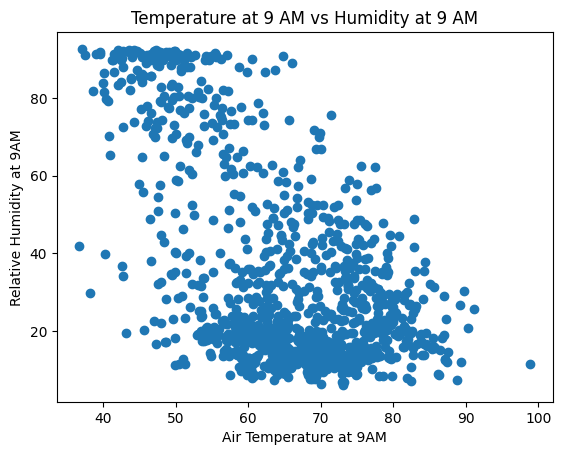

In [ ]:
plt.figure()
plt.scatter(df_raw["air_temp_9am"], df_raw["relative_humidity_9am"])
plt.title("Temperature at 9 AM vs Humidity at 9 AM")
plt.xlabel("Air Temperature at 9AM")
plt.ylabel("Relative Humidity at 9AM")
plt.show()


Histogram (9AM Temperature Distribution)

This helps us show the distribution of temperature values and its frequency. The histogram shows that the majority of air temperature at 9 AM falls under 55 to 80.


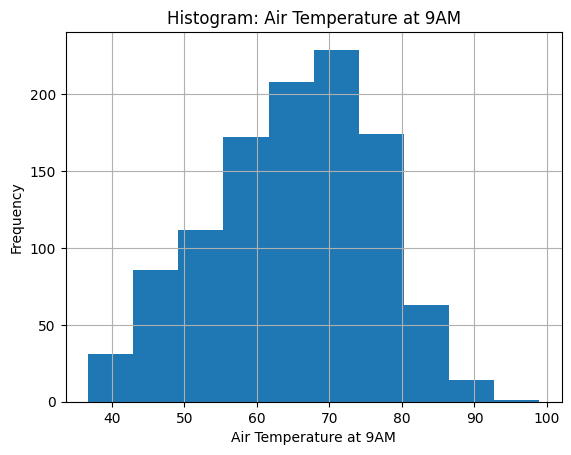

In [191]:
plt.figure()
df_raw["air_temp_9am"].hist()
plt.title("Histogram: Air Temperature at 9AM")
plt.xlabel("Air Temperature at 9AM")
plt.ylabel("Frequency")
plt.show()


Box Plot (Temperature Outliers)

With the help of Box Plot the outlier is easier to see and remove or corrected for better data. Temperature is used as a column for the box plot.


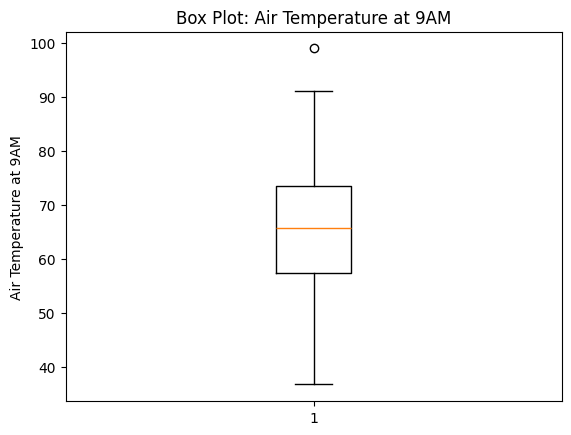

In [192]:
plt.figure()
plt.boxplot(df_raw["air_temp_9am"].dropna())
plt.title("Box Plot: Air Temperature at 9AM")
plt.ylabel("Air Temperature at 9AM")
plt.show()


In [ ]:
#  Missing value report before cleaning
missing_before = df_raw.isnull().sum()
missing_before


number                    0
air_pressure_9am          3
air_temp_9am              5
avg_wind_direction_9am    4
avg_wind_speed_9am        3
max_wind_direction_9am    3
max_wind_speed_9am        4
rain_accumulation_9am     6
rain_duration_9am         3
relative_humidity_9am     0
relative_humidity_3pm     0
dtype: int64

In [ ]:
# Shows rows and column that contain at least 1 missing value
rows_missing = df_raw[df_raw.isnull().any(axis=1)]
rows_missing.shape


(31, 11)

In [195]:
# Shows rows with missing values BEFORE cleaning
rows_missing.head(10)


,number,air_pressure_9am,air_temp_9am,avg_wind_direction_9am,avg_wind_speed_9am,max_wind_direction_9am,max_wind_speed_9am,rain_accumulation_9am,rain_duration_9am,relative_humidity_9am,relative_humidity_3pm
16,16,917.890000,NaN,169.200000,2.192201,196.800000,2.930391,0.0,0.000000,48.990000,51.190000
111,111,915.290000,58.820000,182.600000,15.613841,189.000000,NaN,0.0,0.000000,21.500000,29.690000
177,177,915.900000,NaN,183.300000,4.719943,189.900000,5.346287,0.0,0.000000,29.260000,46.500000
262,262,923.596607,58.380598,47.737753,10.636273,67.145843,13.671423,0.0,NaN,17.990876,16.461685
277,277,920.480000,62.600000,194.400000,2.751436,NaN,3.869906,0.0,0.000000,52.580000,54.030000
334,334,916.230000,75.740000,149.100000,2.751436,187.500000,4.183078,NaN,1480.000000,31.880000,32.900000
358,358,917.440000,58.514000,55.100000,10.021491,NaN,12.705819,0.0,0.000000,13.880000,25.930000
361,361,920.444946,65.801845,49.823346,21.520177,61.886944,25.549112,NaN,40.364018,12.278715,7.618649
381,381,918.480000,66.542000,90.900000,3.467257,89.400000,4.406772,NaN,0.000000,20.640000,14.350000
409,409,NaN,67.853833,65.880616,4.328594,78.570923,5.216734,0.0,0.000000,18.487385,20.356594


In [ ]:
# Using mean value replacement for missing values for each respective column
df_clean = df_raw.copy()

for col in df_clean.columns:
    if df_clean[col].dtype != "object":
        df_clean[col] = df_clean[col].fillna(df_clean[col].mean())

# Missing value report after cleaning
missing_after = df_clean.isnull().sum()
missing_after


number                    0
air_pressure_9am          0
air_temp_9am              0
avg_wind_direction_9am    0
avg_wind_speed_9am        0
max_wind_direction_9am    0
max_wind_speed_9am        0
rain_accumulation_9am     0
rain_duration_9am         0
relative_humidity_9am     0
relative_humidity_3pm     0
dtype: int64

In [ ]:
# Shows the rows after cleaning
df_clean.loc[rows_missing.index].head(10)


,number,air_pressure_9am,air_temp_9am,avg_wind_direction_9am,avg_wind_speed_9am,max_wind_direction_9am,max_wind_speed_9am,rain_accumulation_9am,rain_duration_9am,relative_humidity_9am,relative_humidity_3pm
16,16,917.890000,64.933001,169.200000,2.192201,196.800000,2.930391,0.000000,0.000000,48.990000,51.190000
111,111,915.290000,58.820000,182.600000,15.613841,189.000000,7.019514,0.000000,0.000000,21.500000,29.690000
177,177,915.900000,64.933001,183.300000,4.719943,189.900000,5.346287,0.000000,0.000000,29.260000,46.500000
262,262,923.596607,58.380598,47.737753,10.636273,67.145843,13.671423,0.000000,294.108052,17.990876,16.461685
277,277,920.480000,62.600000,194.400000,2.751436,148.953518,3.869906,0.000000,0.000000,52.580000,54.030000
334,334,916.230000,75.740000,149.100000,2.751436,187.500000,4.183078,0.203079,1480.000000,31.880000,32.900000
358,358,917.440000,58.514000,55.100000,10.021491,148.953518,12.705819,0.000000,0.000000,13.880000,25.930000
361,361,920.444946,65.801845,49.823346,21.520177,61.886944,25.549112,0.203079,40.364018,12.278715,7.618649
381,381,918.480000,66.542000,90.900000,3.467257,89.400000,4.406772,0.203079,0.000000,20.640000,14.350000
409,409,918.882551,67.853833,65.880616,4.328594,78.570923,5.216734,0.000000,0.000000,18.487385,20.356594


In [ ]:
# Dropping or removing rows with missing values
df_clean.loc[rows_missing.index].isnull().sum()


number                    0
air_pressure_9am          0
air_temp_9am              0
avg_wind_direction_9am    0
avg_wind_speed_9am        0
max_wind_direction_9am    0
max_wind_speed_9am        0
rain_accumulation_9am     0
rain_duration_9am         0
relative_humidity_9am     0
relative_humidity_3pm     0
dtype: int64


Outlier handling is done on column `air_temp_9am`.


In [199]:
col = "air_temp_9am"

q1 = df_clean[col].quantile(0.25)
q3 = df_clean[col].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

q1, q3, iqr, lower, upper


(57.353000000000264,
 73.43592021862153,
 16.08292021862127,
 33.22861967206836,
 97.56030054655344)

In [200]:
# Identified outliers
outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]
outliers.head(10)


,number,air_pressure_9am,air_temp_9am,avg_wind_direction_9am,avg_wind_speed_9am,max_wind_direction_9am,max_wind_speed_9am,rain_accumulation_9am,rain_duration_9am,relative_humidity_9am,relative_humidity_3pm
720,720,913.7,98.906,192.7,2.125093,53.4,3.35541,0.0,0.0,11.49,30.02


In [ ]:
# Outlier Handling
df_no_outliers = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)].copy()

df_clean.shape, df_no_outliers.shape


((1095, 11), (1094, 11))

In [ ]:
# Before data reduction
df_no_outliers.shape


(1094, 11)

In [ ]:
# Keep 35% of rows for Data Reduction
df_sampled = df_no_outliers.sample(frac=0.35, random_state=42).copy()

# Drop column
if "number" in df_sampled.columns:
    df_reduced = df_sampled.drop(columns=["number"])
else:
    df_reduced = df_sampled.copy()

# After data reduction
df_sampled.shape, df_reduced.shape


((383, 11), (383, 10))

In [ ]:
# Preview before reduction
df_sampled.head()


,number,air_pressure_9am,air_temp_9am,avg_wind_direction_9am,avg_wind_speed_9am,max_wind_direction_9am,max_wind_speed_9am,rain_accumulation_9am,rain_duration_9am,relative_humidity_9am,relative_humidity_3pm
482,482,915.700000,60.512000,79.100000,8.231939,88.300000,9.439887,0.0,0.000000,16.790000,27.880000
139,139,921.933298,64.618269,73.213445,3.815592,92.033194,4.733501,0.0,0.000000,12.284974,15.887080
88,88,915.914436,69.388873,46.736171,10.976951,64.644682,14.297617,0.0,9.397157,8.498335,12.698546
940,940,918.790000,61.808000,162.900000,3.221194,187.000000,4.183078,0.0,0.000000,25.370000,22.260000
733,733,916.180000,49.568000,181.600000,7.247686,191.000000,8.925391,0.0,0.000000,83.620000,49.950000


In [ ]:
# Preview after reduction
df_reduced.head()


,air_pressure_9am,air_temp_9am,avg_wind_direction_9am,avg_wind_speed_9am,max_wind_direction_9am,max_wind_speed_9am,rain_accumulation_9am,rain_duration_9am,relative_humidity_9am,relative_humidity_3pm
482,915.700000,60.512000,79.100000,8.231939,88.300000,9.439887,0.0,0.000000,16.790000,27.880000
139,921.933298,64.618269,73.213445,3.815592,92.033194,4.733501,0.0,0.000000,12.284974,15.887080
88,915.914436,69.388873,46.736171,10.976951,64.644682,14.297617,0.0,9.397157,8.498335,12.698546
940,918.790000,61.808000,162.900000,3.221194,187.000000,4.183078,0.0,0.000000,25.370000,22.260000
733,916.180000,49.568000,181.600000,7.247686,191.000000,8.925391,0.0,0.000000,83.620000,49.950000


In [206]:
numeric_cols = df_reduced.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols


['air_pressure_9am',
 'air_temp_9am',
 'avg_wind_direction_9am',
 'avg_wind_speed_9am',
 'max_wind_direction_9am',
 'max_wind_speed_9am',
 'rain_accumulation_9am',
 'rain_duration_9am',
 'relative_humidity_9am',
 'relative_humidity_3pm']

In [ ]:
# Before Scaling
df_reduced[numeric_cols].head()


,air_pressure_9am,air_temp_9am,avg_wind_direction_9am,avg_wind_speed_9am,max_wind_direction_9am,max_wind_speed_9am,rain_accumulation_9am,rain_duration_9am,relative_humidity_9am,relative_humidity_3pm
482,915.700000,60.512000,79.100000,8.231939,88.300000,9.439887,0.0,0.000000,16.790000,27.880000
139,921.933298,64.618269,73.213445,3.815592,92.033194,4.733501,0.0,0.000000,12.284974,15.887080
88,915.914436,69.388873,46.736171,10.976951,64.644682,14.297617,0.0,9.397157,8.498335,12.698546
940,918.790000,61.808000,162.900000,3.221194,187.000000,4.183078,0.0,0.000000,25.370000,22.260000
733,916.180000,49.568000,181.600000,7.247686,191.000000,8.925391,0.0,0.000000,83.620000,49.950000


In [ ]:
# Min-Max Scaling
df_scaled = df_reduced.copy()

for c in numeric_cols:
    min_v = df_scaled[c].min()
    max_v = df_scaled[c].max()
    if max_v != min_v:
        df_scaled[c] = (df_scaled[c] - min_v) / (max_v - min_v)
    else:
        df_scaled[c] = 0.0

# After Scaling
df_scaled[numeric_cols].head()


,air_pressure_9am,air_temp_9am,avg_wind_direction_9am,avg_wind_speed_9am,max_wind_direction_9am,max_wind_speed_9am,rain_accumulation_9am,rain_duration_9am,relative_humidity_9am,relative_humidity_3pm
482,0.361463,0.434088,0.178427,0.329746,0.207994,0.285826,0.0,0.000000,0.105884,0.241444
139,0.653694,0.510029,0.160129,0.136567,0.221200,0.121070,0.0,0.000000,0.052765,0.099918
88,0.371516,0.598256,0.077825,0.449817,0.124318,0.455881,0.0,0.000807,0.008116,0.062291
940,0.506329,0.458056,0.438918,0.110568,0.557128,0.101801,0.0,0.000000,0.207051,0.175124
733,0.383966,0.231691,0.497047,0.286693,0.571277,0.267815,0.0,0.000000,0.893880,0.501888


In [209]:
# Discretization of temperature values into different categories such as Cold, Mild and Hot
df_scaled["temp_group"] = pd.cut(
    df_reduced["air_temp_9am"],
    bins=[-100, 50, 75, 150],
    labels=["Cold", "Mild", "Hot"]
)
# Displaying each categories or group count 
df_scaled["temp_group"].value_counts()


temp_group
Mild    249
Hot      75
Cold     59
Name: count, dtype: int64

In [210]:
df_scaled.info()


<class 'pandas.core.frame.DataFrame'>
Index: 383 entries, 482 to 533
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   air_pressure_9am        383 non-null    float64 
 1   air_temp_9am            383 non-null    float64 
 2   avg_wind_direction_9am  383 non-null    float64 
 3   avg_wind_speed_9am      383 non-null    float64 
 4   max_wind_direction_9am  383 non-null    float64 
 5   max_wind_speed_9am      383 non-null    float64 
 6   rain_accumulation_9am   383 non-null    float64 
 7   rain_duration_9am       383 non-null    float64 
 8   relative_humidity_9am   383 non-null    float64 
 9   relative_humidity_3pm   383 non-null    float64 
 10  temp_group              383 non-null    category
dtypes: category(1), float64(10)
memory usage: 33.4 KB


In [211]:
df_scaled.describe()


,air_pressure_9am,air_temp_9am,avg_wind_direction_9am,avg_wind_speed_9am,max_wind_direction_9am,max_wind_speed_9am,rain_accumulation_9am,rain_duration_9am,relative_humidity_9am,relative_humidity_3pm
count,383.000000,383.000000,383.000000,383.000000,383.000000,383.000000,383.000000,383.000000,383.000000,383.000000
mean,0.513367,0.511788,0.384302,0.212353,0.431034,0.203946,0.008994,0.022778,0.301381,0.318225
std,0.148983,0.210265,0.215287,0.202424,0.237803,0.199658,0.074257,0.112698,0.291465,0.257147
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.407407,0.367727,0.147884,0.067522,0.173423,0.061878,0.000000,0.000000,0.085708,0.122315
50%,0.511486,0.535286,0.454772,0.136986,0.530598,0.129155,0.000000,0.000000,0.177452,0.195775
75%,0.614158,0.679328,0.529686,0.299346,0.610718,0.280345,0.000000,0.000000,0.406261,0.496578
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [212]:
analysis_col = "air_pressure_9am"
x = df_reduced[analysis_col]

{
    "min": x.min(),
    "max": x.max(),
    "mean": x.mean(),
    "median": x.median(),
    "mode": x.mode().iloc[0] if not x.mode().empty else np.nan
}


{'min': 907.9900000000024,
 'max': 929.3200000000012,
 'mean': 918.940120212696,
 'median': 918.9000000000004,
 'mode': 914.8000000000048}

In [213]:
q1 = x.quantile(0.25)
q3 = x.quantile(0.75)
iqr = q3 - q1

{
    "range": x.max() - x.min(),
    "q1": q1,
    "q3": q3,
    "iqr": iqr,
    "variance": x.var(),
    "std_dev": x.std()
}


{'range': 21.32999999999879,
 'q1': 916.6800000000029,
 'q3': 921.0900000000087,
 'iqr': 4.410000000005766,
 'variance': 10.09850583280488,
 'std_dev': 3.17781463159903}

In [214]:
corr_matrix = df_reduced.select_dtypes(include=[np.number]).corr()
corr_matrix


,air_pressure_9am,air_temp_9am,avg_wind_direction_9am,avg_wind_speed_9am,max_wind_direction_9am,max_wind_speed_9am,rain_accumulation_9am,rain_duration_9am,relative_humidity_9am,relative_humidity_3pm
air_pressure_9am,1.000000,-0.030438,-0.282894,0.201230,-0.239765,0.202834,-0.160346,-0.191158,-0.412252,-0.451769
air_temp_9am,-0.030438,1.000000,-0.049634,-0.284500,-0.126797,-0.296594,-0.203306,-0.292880,-0.578849,-0.466018
avg_wind_direction_9am,-0.282894,-0.049634,1.000000,-0.457040,0.851668,-0.474051,0.113095,0.147379,0.327255,0.358044
avg_wind_speed_9am,0.201230,-0.284500,-0.457040,1.000000,-0.364486,0.990898,0.007660,0.017804,-0.078735,-0.147344
max_wind_direction_9am,-0.239765,-0.126797,0.851668,-0.364486,1.000000,-0.381182,0.112301,0.137848,0.352252,0.392045
max_wind_speed_9am,0.202834,-0.296594,-0.474051,0.990898,-0.381182,1.000000,0.017802,0.050842,-0.077838,-0.148575
rain_accumulation_9am,-0.160346,-0.203306,0.113095,0.007660,0.112301,0.017802,1.000000,0.797313,0.230103,0.167804
rain_duration_9am,-0.191158,-0.292880,0.147379,0.017804,0.137848,0.050842,0.797313,1.000000,0.344652,0.289002
relative_humidity_9am,-0.412252,-0.578849,0.327255,-0.078735,0.352252,-0.077838,0.230103,0.344652,1.000000,0.871349
relative_humidity_3pm,-0.451769,-0.466018,0.358044,-0.147344,0.392045,-0.148575,0.167804,0.289002,0.871349,1.000000
